# Aperture Sampling Convergence Study

This notebook investigates how RMSE converges to theoretical Airy pattern as we increase the number of photons.

For each N_photons, we run multiple trials and compute:
- Mean RMSE
- Standard deviation of RMSE

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1
from scipy.interpolate import interp1d
from monte_carlo.core import ApertureSimulator
from monte_carlo import metrics

# Set style
sns.set_theme(style="whitegrid", font_scale=1.5)

# Create output directory
import os
output_dir = '../data/aperture_convergence'
os.makedirs(output_dir, exist_ok=True)

# Helper function to compute FWHM
def compute_fwhm(r_centers, intensity):
    """
    Compute Full Width at Half Maximum (FWHM) from radial intensity profile.
    
    Parameters
    ----------
    r_centers : np.ndarray
        Radial distance values
    intensity : np.ndarray
        Normalized intensity values (peak = 1.0)
    
    Returns
    -------
    float
        FWHM value (diameter at half maximum)
    """
    # Find where intensity crosses 0.5
    half_max = 0.5
    
    # Find indices where intensity is above half max
    above_half = intensity >= half_max
    
    if not np.any(above_half):
        return np.nan
    
    # Find the last point above half max (going outward from center)
    try:
        # Find approximate crossing point
        crossing_idx = np.where(np.diff(above_half.astype(int)) < 0)[0]
        
        if len(crossing_idx) == 0:
            return np.nan
        
        # Use first crossing (going outward from center)
        idx = crossing_idx[0]
        
        # Refine with linear interpolation
        r_range = r_centers[idx:idx+2]
        i_range = intensity[idx:idx+2] - half_max
        
        # Linear interpolation to find zero crossing
        r_half_max = r_range[0] - i_range[0] * (r_range[1] - r_range[0]) / (i_range[1] - i_range[0])
        
        fwhm = 2 * r_half_max
        return fwhm
    except:
        return np.nan

## Setup Parameters

In [2]:
# Fixed simulation parameters
wavelength = 0.6328  # microns (632.8 nm - HeNe laser)
focal_length = 10.0  # mm
numerical_aperture = 0.1
n_medium = 1.0

# Convergence study parameters
n_photons_list = [1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000]
n_trials = 10  # Number of trials per N_photons

# Airy parameters
airy_radius = 1.22 * wavelength / numerical_aperture
k_theory = 2 * np.pi * numerical_aperture / wavelength

print(f"Wavelength: {wavelength} μm ({wavelength*1000:.1f} nm)")
print(f"NA: {numerical_aperture}")
print(f"Focal length: {focal_length} mm")
print(f"First Airy zero: {airy_radius:.4f} μm")
print(f"\nN_photons range: {min(n_photons_list)} to {max(n_photons_list)}")
print(f"Trials per N_photons: {n_trials}")

Wavelength: 0.6328 μm (632.8 nm)
NA: 0.1
Focal length: 10.0 mm
First Airy zero: 7.7202 μm

N_photons range: 1000 to 10000000
Trials per N_photons: 10


## Compute Theoretical Airy Pattern

In [3]:
# Create theoretical Airy radial profile
plot_range = 2 * airy_radius
r_bins = np.linspace(0, plot_range, 300)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)

# Theoretical Airy pattern
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

print(f"Radial bins: {len(r_bins)}")
print(f"Radial range: [0, {plot_range:.4f}] μm")

Radial bins: 300
Radial range: [0, 15.4403] μm


## Run Convergence Study

In [4]:
# Storage for results
rmse_results = {}
fwhm_results = {}

# Compute theoretical FWHM
fwhm_theory = compute_fwhm(r_centers, airy_theory)
print(f"Theoretical Airy FWHM: {fwhm_theory:.4f} μm\n")

for n_photons in n_photons_list:
    print(f"\nRunning N_photons = {n_photons}...")
    rmse_trials = []
    fwhm_trials = []
    
    # Create subdirectory for this n_photons
    n_photons_dir = f'{output_dir}/n_photons_{n_photons}'
    os.makedirs(n_photons_dir, exist_ok=True)
    
    for trial in range(n_trials):
        # Create simulator with different seed for each trial
        sim = ApertureSimulator(
            n_photons=n_photons,
            wavelength=wavelength,
            focal_length=focal_length,
            numerical_aperture=numerical_aperture,
            n_medium=n_medium,
            random_seed=trial
        )
        
        # Run simulation
        results = sim.propagate()
        x, y, _ = results['focal_positions']
        
        # Compute radial profile
        r = np.sqrt(x**2 + y**2)
        hist_r, _ = np.histogram(r, bins=r_bins)
        intensity_r = hist_r / bin_areas
        intensity_r = intensity_r / np.max(intensity_r)  # Normalize to peak
        
        # Compute RMSE
        rmse_val = metrics.rmse(intensity_r, airy_theory)
        rmse_trials.append(rmse_val)
        
        # Compute FWHM
        fwhm_val = compute_fwhm(r_centers, intensity_r)
        fwhm_trials.append(fwhm_val)
        
        # Save comparison plot for this trial
        fig, ax = plt.subplots(1, 1, figsize=(10, 7))
        ax.plot(r_centers, airy_theory, 'r-', linewidth=3, label='Theoretical Airy', alpha=0.8)
        ax.plot(r_centers, intensity_r, 'b-', linewidth=2, label=f'Monte Carlo (Trial {trial+1})', alpha=0.7)
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, label='Half Maximum')
        ax.set_xlabel('Radial Distance (μm)', fontsize=14)
        ax.set_ylabel('Normalized Intensity', fontsize=14)
        ax.set_title(f'Focal Plane: Airy vs Monte Carlo\nN_photons = {n_photons}, Trial {trial+1}\nRMSE = {rmse_val:.6f}, FWHM = {fwhm_val:.4f} μm (theory: {fwhm_theory:.4f} μm)', 
                     fontsize=13, fontweight='bold')
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{n_photons_dir}/trial_{trial+1:02d}_comparison.png', dpi=150, bbox_inches='tight')
        plt.close()
    
    # Store results
    rmse_results[n_photons] = {
        'mean': np.mean(rmse_trials),
        'std': np.std(rmse_trials),
        'trials': rmse_trials
    }
    
    fwhm_trials_clean = [f for f in fwhm_trials if not np.isnan(f)]
    fwhm_results[n_photons] = {
        'mean': np.mean(fwhm_trials_clean) if len(fwhm_trials_clean) > 0 else np.nan,
        'std': np.std(fwhm_trials_clean) if len(fwhm_trials_clean) > 0 else np.nan,
        'trials': fwhm_trials,
        'error_vs_theory': np.abs(np.mean(fwhm_trials_clean) - fwhm_theory) if len(fwhm_trials_clean) > 0 else np.nan
    }
    
    print(f"  RMSE: {rmse_results[n_photons]['mean']:.6f} ± {rmse_results[n_photons]['std']:.6f}")
    print(f"  FWHM: {fwhm_results[n_photons]['mean']:.4f} ± {fwhm_results[n_photons]['std']:.4f} μm (error: {fwhm_results[n_photons]['error_vs_theory']:.4f} μm)")
    print(f"  Saved {n_trials} comparison images to {n_photons_dir}/")

print("\nConvergence study complete!")

Theoretical Airy FWHM: 3.2557 μm


Running N_photons = 1000...


  RMSE: 0.133831 ± 0.031419
  FWHM: 0.4394 ± 0.5454 μm (error: 2.8164 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_1000/

Running N_photons = 5000...


  RMSE: 0.101028 ± 0.038766
  FWHM: 1.2893 ± 1.0970 μm (error: 1.9664 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_5000/

Running N_photons = 10000...


  RMSE: 0.073940 ± 0.031309
  FWHM: 2.2805 ± 0.9053 μm (error: 0.9752 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_10000/

Running N_photons = 50000...


  RMSE: 0.034330 ± 0.013711
  FWHM: 2.9517 ± 0.1612 μm (error: 0.3041 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_50000/

Running N_photons = 100000...


  RMSE: 0.027975 ± 0.011103
  FWHM: 3.0157 ± 0.1274 μm (error: 0.2400 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_100000/

Running N_photons = 500000...


  RMSE: 0.010393 ± 0.007408
  FWHM: 3.1895 ± 0.0716 μm (error: 0.0663 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_500000/

Running N_photons = 1000000...


  RMSE: 0.010376 ± 0.006045
  FWHM: 3.1767 ± 0.0624 μm (error: 0.0790 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_1000000/

Running N_photons = 5000000...


  RMSE: 0.002907 ± 0.001050
  FWHM: 3.2350 ± 0.0127 μm (error: 0.0208 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_5000000/

Running N_photons = 10000000...


  RMSE: 0.002939 ± 0.002291
  FWHM: 3.2390 ± 0.0238 μm (error: 0.0167 μm)
  Saved 10 comparison images to ../data/aperture_convergence/n_photons_10000000/

Convergence study complete!


## Plot Results

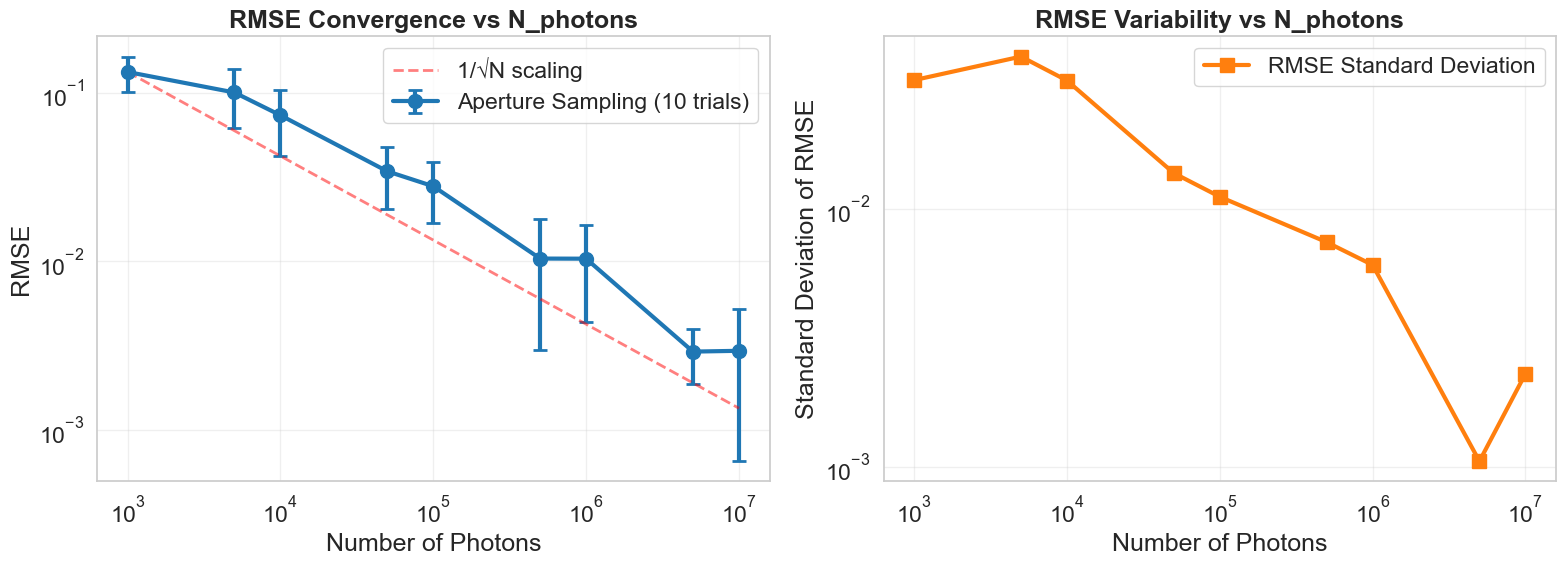


Plot saved to: ../data/aperture_convergence/aperture_convergence.png


In [5]:
# Extract data for plotting
n_photons_array = np.array(n_photons_list)
rmse_mean = np.array([rmse_results[n]['mean'] for n in n_photons_list])
rmse_std = np.array([rmse_results[n]['std'] for n in n_photons_list])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: RMSE vs N_photons (log scale)
ax = axes[0]
ax.errorbar(n_photons_array, rmse_mean, yerr=rmse_std, 
            marker='o', markersize=10, linewidth=3, capsize=5, capthick=2,
            label=f'Aperture Sampling ({n_trials} trials)', color='tab:blue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Photons')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Convergence vs N_photons', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add theoretical 1/sqrt(N) scaling line
n_ref = n_photons_array[0]
rmse_ref = rmse_mean[0]
theoretical_scaling = rmse_ref * np.sqrt(n_ref / n_photons_array)
ax.plot(n_photons_array, theoretical_scaling, '--', linewidth=2, 
        alpha=0.5, color='red', label='1/√N scaling')
ax.legend()

# Plot 2: Standard deviation vs N_photons
ax = axes[1]
ax.plot(n_photons_array, rmse_std, marker='s', markersize=10, 
        linewidth=3, color='tab:orange', label='RMSE Standard Deviation')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Photons')
ax.set_ylabel('Standard Deviation of RMSE')
ax.set_title('RMSE Variability vs N_photons', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/aperture_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {output_dir}/aperture_convergence.png")

## Summary Statistics

In [6]:
print("\n" + "="*100)
print("APERTURE SAMPLING CONVERGENCE STUDY")
print("="*100)
print(f"Theoretical Airy FWHM: {fwhm_theory:.4f} μm")
print("="*100)
print(f"{'N_photons':<15} {'RMSE (mean)':<15} {'RMSE (std)':<15} {'FWHM (mean)':<15} {'FWHM (std)':<15} {'FWHM Error':<15}")
print("-"*100)
for n in n_photons_list:
    mean_rmse = rmse_results[n]['mean']
    std_rmse = rmse_results[n]['std']
    mean_fwhm = fwhm_results[n]['mean']
    std_fwhm = fwhm_results[n]['std']
    fwhm_err = fwhm_results[n]['error_vs_theory']
    print(f"{n:<15} {mean_rmse:<15.6f} {std_rmse:<15.6f} {mean_fwhm:<15.4f} {std_fwhm:<15.4f} {fwhm_err:<15.4f}")
print("="*100)


APERTURE SAMPLING CONVERGENCE STUDY
Theoretical Airy FWHM: 3.2557 μm
N_photons       RMSE (mean)     RMSE (std)      FWHM (mean)     FWHM (std)      FWHM Error     
----------------------------------------------------------------------------------------------------
1000            0.133831        0.031419        0.4394          0.5454          2.8164         
5000            0.101028        0.038766        1.2893          1.0970          1.9664         
10000           0.073940        0.031309        2.2805          0.9053          0.9752         
50000           0.034330        0.013711        2.9517          0.1612          0.3041         
100000          0.027975        0.011103        3.0157          0.1274          0.2400         
500000          0.010393        0.007408        3.1895          0.0716          0.0663         
1000000         0.010376        0.006045        3.1767          0.0624          0.0790         
5000000         0.002907        0.001050        3.2350       